<font color='red'><b>**WARNING**</b></font> <br/>
어떠한 사유로도 임의로 복사, 촬영, 녹음, 복제, 보관, 전송하거나 허가 받지 않은 저장매체를 이용한 보관, 제3자에게 누설, 공개 또는 사용하는 등의 무단 사용 및 불법 배포 시 법적 조치를 받을 수 있습니다. <br/>

<div style="text-align: right; color: #7f8c8d; font-size: 0.9em; margin-top: 20px;">
📝 Author: 박사홍 (Sahong Pak)</br>
📧 Contact: sahong.pak@gmail.com</br>
📌 Version: v2.0</br>
📅 Last Updated: 2026-03-12</br>
</div>

</br>

In [1]:
# TODO 0: 실습을 위해 아래 패키지를 import 해주세요.

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

</br>

# 학습 내용
>이번 장에서는 <strong>MLP 모델 구현 및 학습(MLP Implementation & Training)</strong>에 대해 학습합니다.</br></br>
>다층 퍼셉트론 모델 설계, 손실 함수, 옵티마이저, 학습/평가 루프를 학습해봅시다.

</br>

# MLP (Multi-Layer Perceptron)
> <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">여러 완전 연결층(Fully Connected Layer)</mark>을 쌓아 비선형 문제를 해결하는 신경망입니다.

> 단일 선형 레이어(`nn.Linear`)만으로는 왜 부족할까요?</br></br>
> 선형 변환을 아무리 여러 번 쌓아도 $W_2(W_1 x + b_1) + b_2 = W' x + b'$로 축약되어, 레이어를 100개 쌓아도 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">표현력은 단층 선형 모델과 같습니다</mark>. </br></br>
> ReLU, Sigmoid 같은 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">비선형 함수</mark>를 각 레이어 사이에 삽입하면, 등가 축약이 불가능해지고, 모델이 곡선·경계·복잡한 패턴을 학습할 수 있게 됩니다. XOR 문제처럼 직선 하나로 분리 불가능한 데이터도 MLP는 해결할 수 있습니다.</br></br>
 > 은닉층은 첫 번째 층에서 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">저수준 패턴</mark>(엣지, 기울기)을 추출하고, 깊은 층에서 이를 조합해 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">고수준 개념</mark>(형태, 범주)을 표현합니다. </br></br>
 > MLP는 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">비선형 활성화 함수로 선형 모델의 한계를 돌파</mark>하는 가장 기본적인 신경망입니다.

In [2]:
# TODO 1: Digits 데이터셋을 로드하고 피처와 타겟을 분리해봅시다.

from sklearn.datasets import load_digits

digits_dataset = load_digits()
features = digits_dataset.data
target = digits_dataset.target

print(f"데이터 shape: {features.shape}, 클래스 수: {len(set(target))}")

데이터 shape: (1797, 64), 클래스 수: 10


In [3]:
# TODO 2: 데이터를 학습용과 테스트용으로 분할해봅시다. (test_size=0.2, random_state=42, stratify=target)

from sklearn.model_selection import train_test_split

features_train, features_test, target_train, target_test = train_test_split(
    features, target, test_size=0.2, random_state=42, stratify=target
)

print(f"학습 데이터: {features_train.shape}, 테스트 데이터: {features_test.shape}")

학습 데이터: (1437, 64), 테스트 데이터: (360, 64)


In [4]:
# TODO 3: StandardScaler로 학습 데이터를 표준화하고, 테스트 데이터에는 transform만 적용해봅시다.

from sklearn.preprocessing import StandardScaler

standard_scaler = StandardScaler()
features_train_scaled = standard_scaler.fit_transform(features_train)
features_test_scaled = standard_scaler.transform(features_test)

print(f"스케일링 후 - 평균: {features_train_scaled[:, 0].mean():.2f}, 표준편차: {features_train_scaled[:, 0].std():.2f}")

스케일링 후 - 평균: 0.00, 표준편차: 0.00


In [5]:
# TODO 4: NumPy 배열을 PyTorch Tensor로 변환해봅시다. (features는 float, target은 long)

features_train_tensor = torch.from_numpy(features_train_scaled).float()
target_train_tensor = torch.from_numpy(target_train).long()
features_test_tensor = torch.from_numpy(features_test_scaled).float()
target_test_tensor = torch.from_numpy(target_test).long()

print(f"Tensor shape: {features_train_tensor.shape}, dtype: {features_train_tensor.dtype}")

Tensor shape: torch.Size([1437, 64]), dtype: torch.float32


<div style="text-align:center">

</div>

In [6]:
# TODO 5: TensorDataset과 DataLoader를 생성해봅시다. (batch_size=32, 학습은 shuffle=True)

from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(features_train_tensor, target_train_tensor)
test_dataset = TensorDataset(features_test_tensor, target_test_tensor)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
validation_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"학습 배치 수: {len(train_loader)}, 검증 배치 수: {len(validation_loader)}")

학습 배치 수: 45, 검증 배치 수: 12


<div style="text-align:center">

</div>

In [7]:
# TODO 6: 신경망 기본 클래스를 상속하는 MLP 클래스를 정의해봅시다.

class MLP(nn.Module):

    # TODO 6-1: input_dim (입력차원), num_classes (클래스 수), hidden_dims (은닉층 차원), dropout (드롭아웃 비율)을 인자로 받아봅시다.
    def __init__(self, input_dim, num_classes, hidden_dims=(128, 64), dropout=0.2):
        super().__init__()

        # TODO 6-2: 빈 layers 리스트를 만들고, previous_dim을 input_dim으로 초기화해봅시다.
        layers = []
        previous_dim = input_dim

        # TODO 6-3: hidden_dims를 순회하며 은닉층 블록을 반복 생성해봅시다.
        for hidden_dim in hidden_dims:

            # TODO 6-3-1: nn.Linear(previous_dim, hidden_dim) 완전연결층을 추가해봅시다.
            layers.append(nn.Linear(previous_dim, hidden_dim))

            # TODO 6-3-2: nn.ReLU() 활성화 함수를 추가해봅시다.
            layers.append(nn.ReLU())

            # TODO 6-3-3: nn.Dropout(dropout) 정규화를 추가해봅시다.
            layers.append(nn.Dropout(dropout))

            # TODO 6-3-4: previous_dim을 hidden_dim으로 갱신해봅시다.
            previous_dim = hidden_dim

        # TODO 6-4: 마지막 은닉층에서 num_classes로 연결하는 출력층을 추가해봅시다.
        layers.append(nn.Linear(previous_dim, num_classes))

        # TODO 6-5: layers를 nn.Sequential로 묶어 self.network에 저장해봅시다.
        self.network = nn.Sequential(*layers)

    def forward(self, input_tensor):

        # TODO 6-6: self.network에 입력을 통과시켜 반환해봅시다.
        return self.network(input_tensor)

In [8]:
# TODO 7: Digits 데이터셋에 맞춰 MLP 모델을 생성하고 구조를 확인해봅시다.
#  - input_dim=64 (8x8 픽셀), num_classes=10 (숫자 0-9)으로 MLP를 생성해봅시다.
#  - print로 모델 구조를 출력해봅시다.

mlp_model = MLP(input_dim=64, num_classes=10)
print(mlp_model)

MLP(
  (network): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=10, bias=True)
  )
)


</br>

## 손실 함수와 옵티마이저

<table style="width:100%">
  <thead>
    <tr>
      <th style="text-align:center">손실 함수</th>
      <th style="text-align:center">용도</th>
    </tr>
  </thead>
  <tbody>
    <tr><td style="text-align:center"><code>nn.CrossEntropyLoss()</code></td><td style="text-align:center">다중 분류 (Softmax 포함)</td></tr>
    <tr><td style="text-align:center"><code>nn.BCEWithLogitsLoss()</code></td><td style="text-align:center">이진 분류 (Sigmoid 포함)</td></tr>
    <tr><td style="text-align:center"><code>nn.MSELoss()</code></td><td style="text-align:center">회귀</td></tr>
  </tbody>
</table>

In [9]:
# TODO 8: 다중 분류용 손실 함수와 Adam 옵티마이저(lr=1e-3, weight_decay=1e-4)를 설정해봅시다.

cross_entropy = nn.CrossEntropyLoss()
optimizer = optim.Adam(mlp_model.parameters(), lr=1e-3, weight_decay=1e-4)

💡CrossEntropyLoss 주의
> `nn.CrossEntropyLoss`는 내부에 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">Softmax를 포함</mark>합니다.</br>
> 모델의 마지막 레이어에 Softmax를 추가하면 이중 적용됩니다.

</br>

## 학습 루프 (Training Loop)

In [10]:
# TODO 9: epochs와 기록용 리스트(train_loss_list, train_accuracy_list, validation_loss_list, validation_accuracy_list)를 초기화해봅시다.
epochs = 50
train_loss_list = []
train_accuracy_list = []
validation_loss_list = []
validation_accuracy_list = []

<div style="text-align:center">

</div>

In [11]:
# TODO 10: 각 에폭마다 학습/검증을 수행하며 손실과 정확도를 기록해봅시다.

for epoch in range(epochs):

    # TODO 10-1: 모델을 학습 모드로 전환해봅시다.
    mlp_model.train()
    total_loss, correct, total = 0, 0, 0

    for features_batch, target_batch in train_loader:

        # TODO 10-2: 기울기를 초기화해봅시다.
        optimizer.zero_grad()

        # TODO 10-3: 순전파로 예측값을 구해봅시다.
        output = mlp_model(features_batch)

        # TODO 10-4: 손실을 계산해봅시다.
        loss = cross_entropy(output, target_batch)

        # TODO 10-5: 역전파를 수행해봅시다.
        loss.backward()

        # TODO 10-6: 파라미터를 업데이트해봅시다.
        optimizer.step()

        # TODO 10-7: 배치별 손실과 정확도를 누적해봅시다.
        total_loss += loss.item() * len(target_batch)
        correct += (output.argmax(1) == target_batch).sum().item()
        total += len(target_batch)

    # TODO 10-8: 에폭 평균 학습 손실과 정확도를 기록해봅시다.
    train_loss = total_loss / total
    train_accuracy = correct / total
    train_loss_list.append(train_loss)
    train_accuracy_list.append(train_accuracy)

    # TODO 10-9: 모델을 평가 모드로 전환해봅시다.
    mlp_model.eval()
    validation_correct, validation_total, validation_loss_sum = 0, 0, 0

    # TODO 10-10: 기울기 추적을 비활성화하고 검증을 수행해봅시다.
    with torch.no_grad():
        for features_batch, target_batch in validation_loader:
            output = mlp_model(features_batch)
            loss = cross_entropy(output, target_batch)
            validation_loss_sum += loss.item() * len(target_batch)
            validation_correct += (output.argmax(1) == target_batch).sum().item()
            validation_total += len(target_batch)

    # TODO 10-11: 에폭 평균 검증 손실과 정확도를 기록해봅시다.
    validation_loss = validation_loss_sum / validation_total
    validation_accuracy = validation_correct / validation_total
    validation_loss_list.append(validation_loss)
    validation_accuracy_list.append(validation_accuracy)

    # TODO 10-12: 10 에폭마다 결과를 출력해봅시다.
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:2d}: Loss={train_loss:.4f}, "
              f"Train Acc={train_accuracy:.2%}, Val Acc={validation_accuracy:.2%}")

Epoch 10: Loss=0.0679, Train Acc=98.47%, Val Acc=97.78%
Epoch 20: Loss=0.0238, Train Acc=99.44%, Val Acc=98.06%
Epoch 30: Loss=0.0120, Train Acc=99.79%, Val Acc=97.78%
Epoch 40: Loss=0.0074, Train Acc=99.86%, Val Acc=98.06%
Epoch 50: Loss=0.0081, Train Acc=99.86%, Val Acc=98.61%


💡model.train() vs model.eval()
> `train()`: Dropout 활성화, BatchNorm 학습 통계 사용</br>
> `eval()`: Dropout 비활성화, BatchNorm 고정 통계 사용</br>
> <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">평가 시 반드시 eval() 모드로 전환</mark>하세요.

</br>

## 학습 곡선 (Learning Curves)

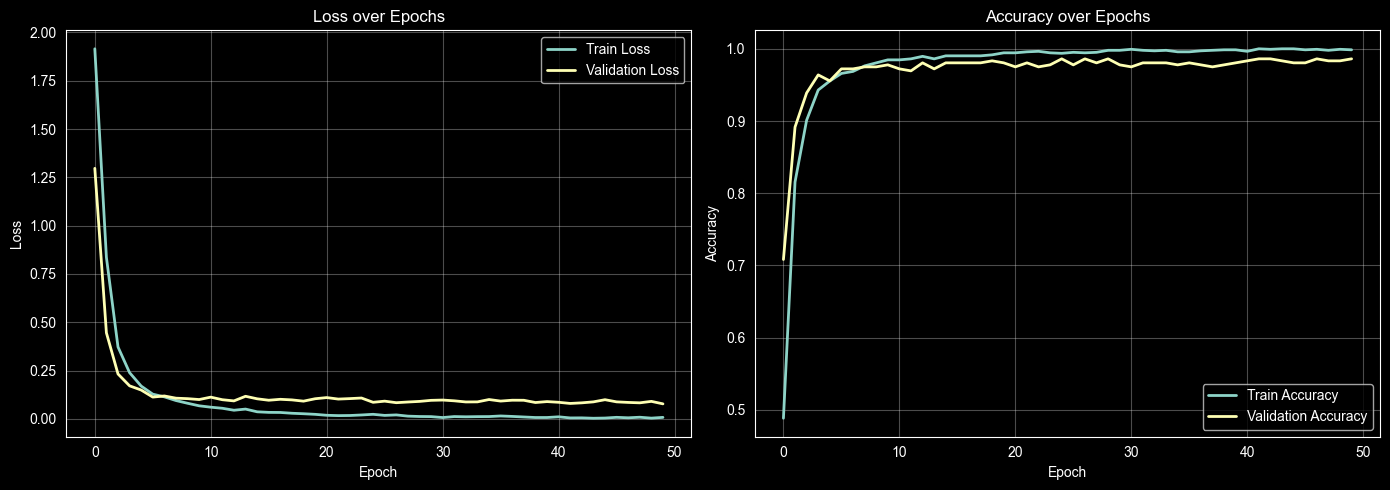

In [12]:
# TODO 11: 학습 곡선(Loss, Accuracy)을 시각화해봅시다.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss 그래프
axes[0].plot(train_loss_list, label="Train Loss", linewidth=2)
axes[0].plot(validation_loss_list, label="Validation Loss", linewidth=2)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss over Epochs")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy 그래프
axes[1].plot(train_accuracy_list, label="Train Accuracy", linewidth=2)
axes[1].plot(validation_accuracy_list, label="Validation Accuracy", linewidth=2)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy over Epochs")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

💡학습 곡선 해석
> **좋은 학습**: Train/Validation Loss가 함께 감소하고 Accuracy가 함께 증가</br>
> **과적합 신호**: Train Loss는 감소하지만 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">Validation Loss가 다시 증가</mark></br>
> **학습 부족**: Loss가 계속 완만히 감소하면 epoch를 늘려볼 수 있습니다.

</br>

## Early Stopping과 체크포인트

In [13]:
# TODO 12: 최적 검증 손실을 무한대로, patience를 5로 초기화하고, 검증 손실이 최적보다 작으면 갱신한 뒤 모델의 가중치를 파일로 저장해봅시다.

best_validation_loss = float("inf")
patience = 5

if validation_loss < best_validation_loss:
    best_validation_loss = validation_loss
    torch.save(mlp_model.state_dict(), "best_model.pt")
    print(f"  ✓ Best model saved (validation_loss={validation_loss:.4f})")

  ✓ Best model saved (validation_loss=0.0780)


💡state_dict vs 전체 모델 저장
> `state_dict()`: <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">가중치만 저장</mark> (권장, 유연함)</br>
> `torch.save(model)`: 전체 모델 저장 (환경 의존성 생김)

## 모델 로드

In [14]:
# TODO 13: 저장된 가중치를 불러와 모델에 적용하고, 평가 모드로 전환해봅시다.

loaded_model = MLP(input_dim=64, num_classes=10)
loaded_model.load_state_dict(torch.load("best_model.pt", weights_only=True))
loaded_model.eval()
print("모델 로드 완료")

모델 로드 완료


💡로드 순서
> 모델 구조를 먼저 생성한 후 `load_state_dict()`로 가중치를 불러옵니다.</br>
> 로드 후 반드시 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">eval() 모드</mark>로 전환하세요.

</br>

# GPU 활용
> <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">CUDA GPU</mark>가 있으면 GPU를, 없으면 CPU를 자동으로 선택합니다.

In [15]:
# TODO 14: CUDA GPU 사용 가능 여부에 따라 device를 설정하고, 모델과 배치 데이터를 해당 장치로 이동해봅시다.

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 장치: {device}")

mlp_model = mlp_model.to(device)

# 배치 데이터도 같은 장치로 이동
sample_features, sample_target = next(iter(train_loader))
sample_features = sample_features.to(device)
sample_target = sample_target.to(device)

사용 장치: cpu


💡.to(device) 사용법
> 모델과 데이터 텐서 모두 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">같은 장치</mark>에 있어야 합니다.</br>
> 학습 루프 내에서 배치마다 `.to(device)`를 호출하세요.